In [ ]:
!pip install gdown

import gdown
import zipfile
import os

url = "https://drive.google.com/file/d/1ZEyNMEO43u3qhJAwJeBZxFBEYc_pVYZQ/view"

file_id = url.split('/d/')[1].split('/')[0]
output = "dataset.zip"

gdown.download(f"https://drive.google.com/uc?id={file_id}", output, quiet=False)

with zipfile.ZipFile(output, 'r') as zip_ref:
    zip_ref.extractall("data")

print("Files:", os.listdir("data"))

Downloading...
From (original): https://drive.google.com/uc?id=1ZEyNMEO43u3qhJAwJeBZxFBEYc_pVYZQ
From (redirected): https://drive.google.com/uc?id=1ZEyNMEO43u3qhJAwJeBZxFBEYc_pVYZQ&confirm=t&uuid=ce1bd7be-2204-4b24-b1c5-e1c1dd43e71b
To: /content/dataset.zip
100%|██████████| 1.13G/1.13G [00:14<00:00, 75.9MB/s]


Files: ['dataset', '__MACOSX']


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import numpy as np
import os
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

In [ ]:
for root, dirs, files in os.walk("data"):
    print(root, "->", len(files), "files")

data -> 0 files
data/dataset -> 1 files
data/dataset/val -> 1 files
data/dataset/val/vort -> 2500 files
data/dataset/val/sphere -> 2500 files
data/dataset/val/no -> 2500 files
data/dataset/train -> 1 files
data/dataset/train/vort -> 10000 files
data/dataset/train/sphere -> 10000 files
data/dataset/train/no -> 10000 files
data/__MACOSX -> 0 files
data/__MACOSX/dataset -> 1 files
data/__MACOSX/dataset/val -> 1 files
data/__MACOSX/dataset/train -> 1 files


In [ ]:
import numpy as np

class LensDataset(Dataset):
    def __init__(self, data_dir, transform=None):
        self.images = []
        self.labels = []
        self.transform = transform

        classes = [c for c in os.listdir(data_dir) if not c.startswith('.')]
        classes.sort()

        for label, cls in enumerate(classes):
            cls_path = os.path.join(data_dir, cls)

            for file in os.listdir(cls_path):
                file_path = os.path.join(cls_path, file)

                # ✅ Only take .npy files
                if file.endswith(".npy"):
                    self.images.append(file_path)
                    self.labels.append(label)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = np.load(self.images[idx])  # ✅ load numpy array

        # Convert to tensor
        img = torch.tensor(img, dtype=torch.float32)

        # Ensure shape is (C, H, W)
        if len(img.shape) == 2:
            img = img.unsqueeze(0)  # (1, H, W)

        return img, self.labels[idx]

In [ ]:
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

dataset = LensDataset("data/dataset/train", transform=transform)

train_size = int(0.9 * len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

print("Train size:", len(train_dataset))
print("Test size:", len(test_dataset))

Train size: 27000
Test size: 3000


In [ ]:
class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.AdaptiveAvgPool2d((4, 4))  # 🔥 FIX
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 4 * 4, 128),  # always correct now
            nn.ReLU(),
            nn.Linear(128, 3)
        )

    def forward(self, x):
        x = self.conv(x)
        x = self.fc(x)
        return x

In [ ]:
batch = next(iter(train_loader))
print(type(batch[0]), batch[0].shape)

<class 'torch.Tensor'> torch.Size([32, 1, 150, 150])


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CNNModel().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

for epoch in range(5):
    model.train()
    total_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss}")

Epoch 1, Loss: 927.3045809268951
Epoch 2, Loss: 927.4235682487488
Epoch 3, Loss: 927.3320813179016
Epoch 4, Loss: 927.3378849029541
Epoch 5, Loss: 927.3245310783386


In [ ]:
model.eval()
y_true = []
y_scores = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)

        probs = torch.softmax(outputs, dim=1).cpu().numpy()
        y_scores.extend(probs)
        y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_scores = np.array(y_scores)

auc = roc_auc_score(y_true, y_scores, multi_class='ovr')
print("AUC Score:", auc)

AUC Score: 0.48856668795286334


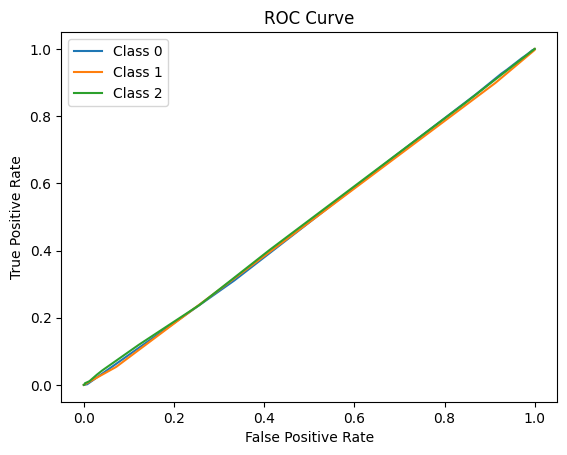

In [ ]:
for i in range(3):
    fpr, tpr, _ = roc_curve(y_true == i, y_scores[:, i])
    plt.plot(fpr, tpr, label=f"Class {i}")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()